# ResNet-152 — Pretrained Model: Predict on 10 Images
**Dataset:** CIFAR-10 | **Weights:** ImageNet Pretrained

In [10]:
!pip install torch torchvision matplotlib requests pillow --quiet

In [11]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import warnings
from PIL import Image

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

PyTorch  : 2.10.0+cpu
Device   : cpu


## Step 1 — Load Pretrained ResNet-152

In [12]:
print("Loading ResNet-152 with ImageNet pretrained weights...")

model = models.resnet152(pretrained=True)
model = model.to(device)
model.eval()  # evaluation mode — disables dropout & batchnorm training behavior

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded!")
print(f"   Parameters : {total_params:,}")
print(f"   Model Size : ~{total_params * 4 / 1e6:.0f} MB")

Loading ResNet-152 with ImageNet pretrained weights...
Model loaded!
   Parameters : 60,192,808
   Model Size : ~241 MB


## Step 2 — Load ImageNet Class Labels

In [13]:
url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
imagenet_labels = requests.get(url, timeout=15).json()
print(f"Loaded {len(imagenet_labels)} ImageNet class labels")

Loaded 1000 ImageNet class labels


## Step 3 — Define Preprocessing Transform

In [14]:
# ResNet-152 expects 224x224 images normalized with ImageNet stats
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])
print("✅ Transform: Resize(224x224) → ToTensor → Normalize (ImageNet stats)")

✅ Transform: Resize(224x224) → ToTensor → Normalize (ImageNet stats)


## Step 4 — Load CIFAR-10, Pick 1 Image Per Class

In [15]:
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

print("Downloading CIFAR-10 test set...")
cifar10 = datasets.CIFAR10(root='./data', train=False, download=True,
                            transform=transforms.ToTensor())

# Pick one image per class (10 total)
selected = {}  # class_idx -> PIL image
for img_tensor, label in cifar10:
    if label not in selected:
        selected[label] = transforms.ToPILImage()(img_tensor)
    if len(selected) == 10:
        break

print(f"Selected 10 images — one per class:")
for idx in sorted(selected):
    print(f"   {idx}: {cifar10_classes[idx]}")

Selected 10 images — one per class:
   0: airplane
   1: automobile
   2: bird
   3: cat
   4: deer
   5: dog
   6: frog
   7: horse
   8: ship
   9: truck


## Step 5 — Run Predictions

In [16]:
results = []

print(f"{'#':<4} {'True Label':<12} {'Top-1 Prediction':<28} {'Confidence':>10}")
print("-" * 60)

with torch.no_grad():
    for i, class_idx in enumerate(sorted(selected.keys())):
        pil_img = selected[class_idx]
        true_label = cifar10_classes[class_idx]

        # Preprocess and add batch dimension
        inp = transform(pil_img).unsqueeze(0).to(device)  # shape: [1, 3, 224, 224]

        # Forward pass
        output = model(inp)                          # raw logits: [1, 1000]
        probs  = torch.softmax(output, dim=1)        # convert to probabilities

        # Get top-3
        top3_probs, top3_idxs = torch.topk(probs, 3, dim=1)
        top3_probs = top3_probs.squeeze().cpu().numpy()
        top3_idxs  = top3_idxs.squeeze().cpu().numpy()

        top1_name = imagenet_labels[top3_idxs[0]]
        top1_conf = top3_probs[0] * 100

        results.append({
            "num":        i + 1,
            "true_label": true_label,
            "top1_name":  top1_name,
            "top1_conf":  top1_conf,
            "top3_probs": top3_probs,
            "top3_idxs":  top3_idxs,
            "pil_img":    pil_img,
        })

        print(f"{i+1:<4} {true_label:<12} {top1_name:<28} {top1_conf:>9.2f}%")

print("-" * 60)
print(" Done!")

#    True Label   Top-1 Prediction             Confidence
------------------------------------------------------------
1    airplane     dust jacket                      26.81%
2    automobile   moving van                       22.31%
3    bird         Geoffroy's spider monkey         10.05%
4    cat          fox squirrel                     91.75%
5    deer         grey whale                       57.90%
6    dog          Japanese Chin                    64.64%
7    frog         tailed frog                      63.13%
8    horse        Arctic fox                       15.40%
9    ship         motorboat                        92.04%
10   truck        moving van                       99.89%
------------------------------------------------------------
 Done!


## Step 6 — Visualize: Images + Predictions

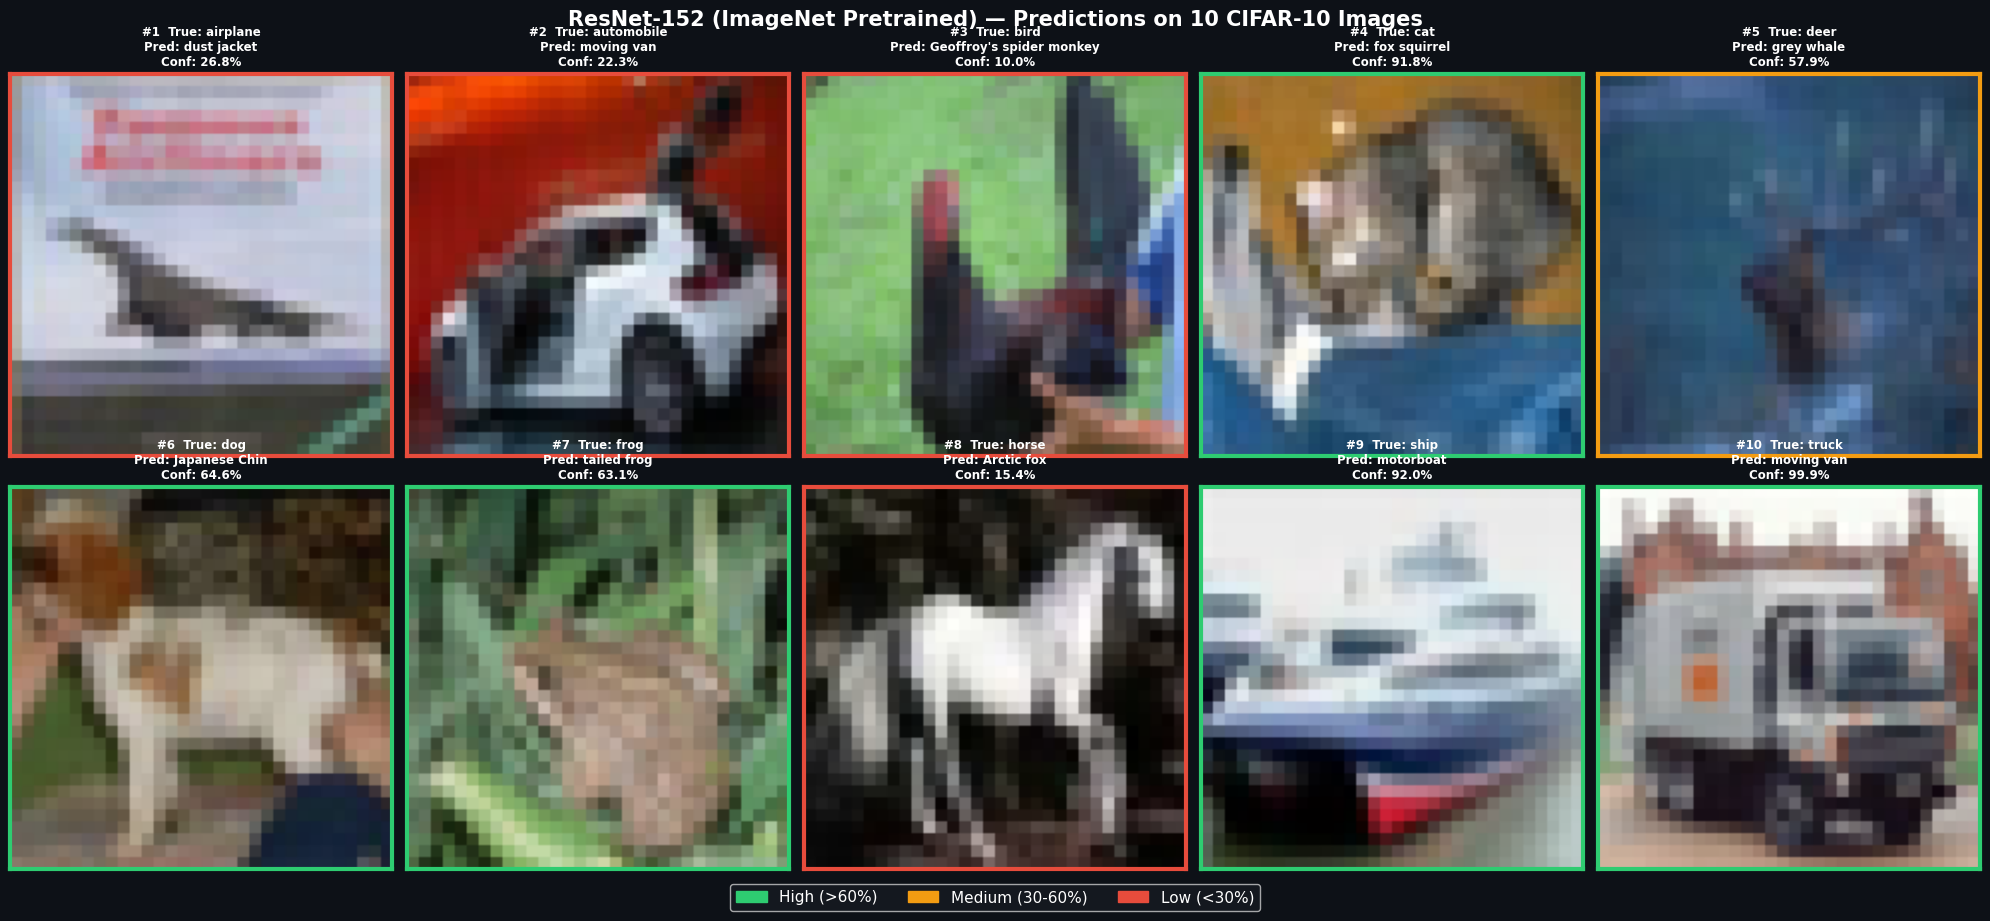

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("ResNet-152 (ImageNet Pretrained) — Predictions on 10 CIFAR-10 Images",
             color='white', fontsize=15, fontweight='bold')

for ax, res in zip(axes.flatten(), results):
    ax.set_facecolor('#161b22')
    ax.imshow(res['pil_img'].resize((128, 128), Image.NEAREST))

    # Border color by confidence
    c = res['top1_conf']
    border = '#2ecc71' if c > 60 else ('#f39c12' if c > 30 else '#e74c3c')
    for spine in ax.spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(3)

    ax.set_title(
        f"#{res['num']}  True: {res['true_label']}\n"
        f"Pred: {res['top1_name']}\n"
        f"Conf: {res['top1_conf']:.1f}%",
        color='white', fontsize=8.5, fontweight='bold'
    )
    ax.set_xticks([]); ax.set_yticks([])

patches = [
    mpatches.Patch(color='#2ecc71', label='High (>60%)'),
    mpatches.Patch(color='#f39c12', label='Medium (30-60%)'),
    mpatches.Patch(color='#e74c3c', label='Low (<30%)'),
]
fig.legend(handles=patches, loc='lower center', ncol=3,
           facecolor='#161b22', labelcolor='white', fontsize=11,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## Step 7 — Top-3 Confidence Bar Charts

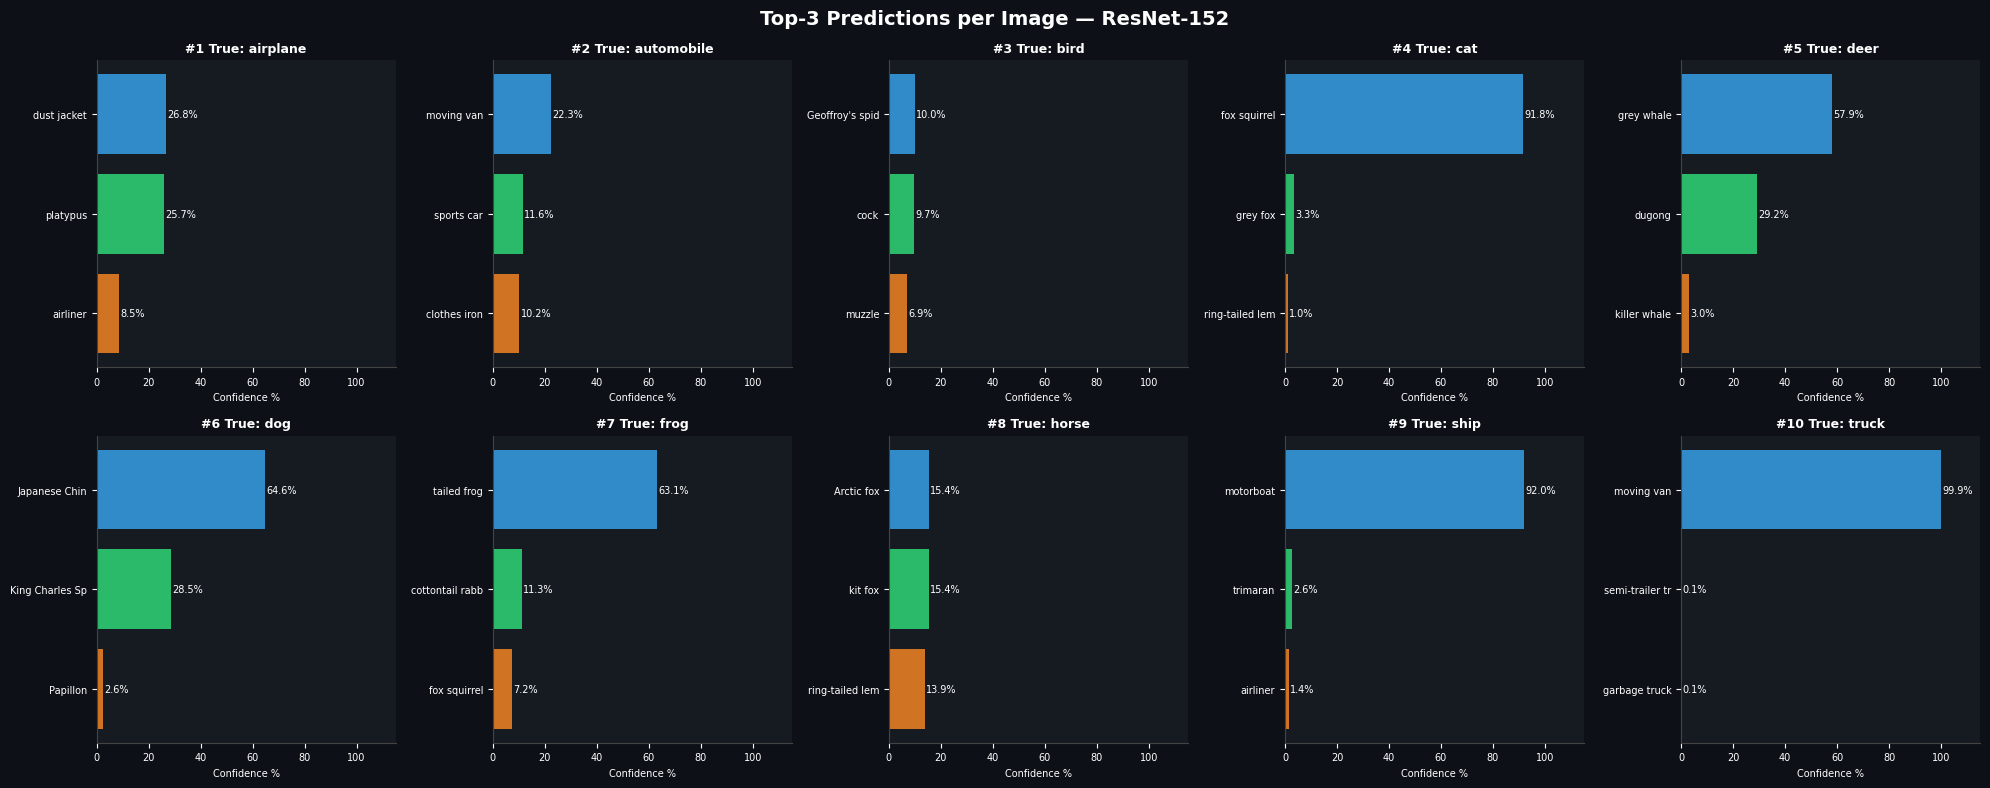

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("Top-3 Predictions per Image — ResNet-152",
             color='white', fontsize=14, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e67e22']

for ax, res in zip(axes.flatten(), results):
    ax.set_facecolor('#161b22')
    labels = [imagenet_labels[i][:15] for i in res['top3_idxs']]
    confs  = [p * 100 for p in res['top3_probs']]

    bars = ax.barh(labels[::-1], confs[::-1], color=colors[::-1], alpha=0.9)
    for bar, conf in zip(bars, confs[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{conf:.1f}%", va='center', color='white', fontsize=7)

    ax.set_xlim(0, 115)
    ax.set_title(f"#{res['num']} True: {res['true_label']}",
                 color='white', fontsize=9, fontweight='bold')
    ax.tick_params(colors='white', labelsize=7)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.set_xlabel("Confidence %", color='white', fontsize=7)

plt.tight_layout()
plt.savefig("top3_bars.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()